## Regression Assignment

#### Assignment No. 11

#### Data File: housing.csv

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing   import StandardScaler

from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm             import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi':120, 'font.size':11, 'axes.titleweight':'bold'})


In [2]:
df = pd.read_csv(r"G:\Jupyter Notebook\Practice Data Files\housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [5]:
df.shape

(20640, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


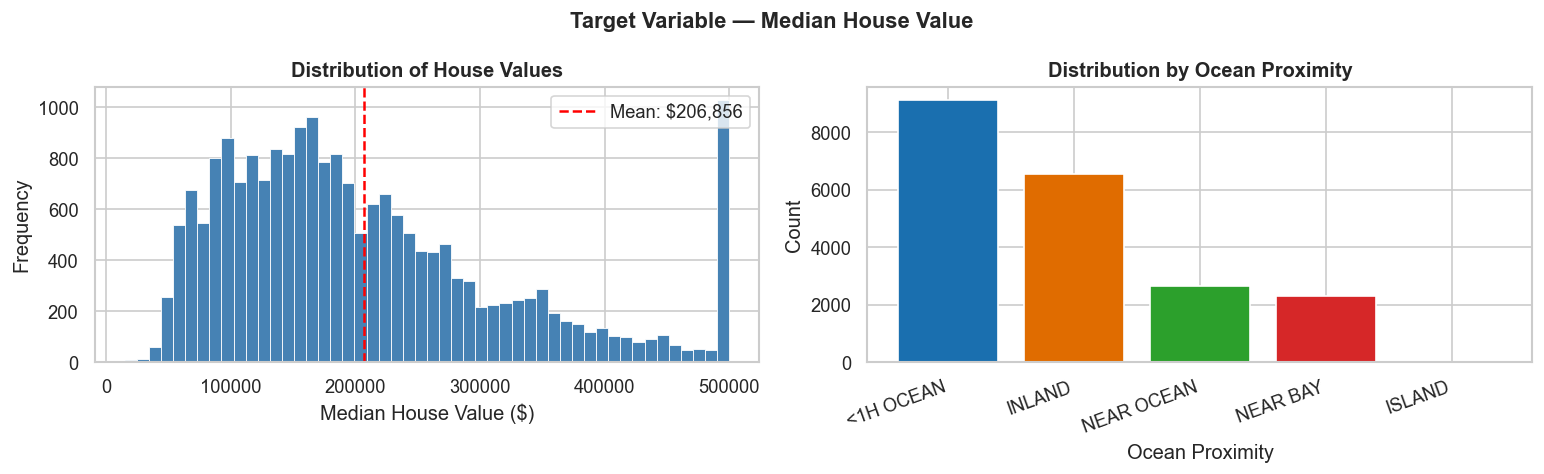

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Target Variable — Median House Value', fontweight='bold')

axes[0].hist(df['median_house_value'], bins=50,
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['median_house_value'].mean(), color='red',
                linestyle='--', label=f'Mean: ${df["median_house_value"].mean():,.0f}')
axes[0].set_title('Distribution of House Values')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()


ocean_counts = df['ocean_proximity'].value_counts()
axes[1].bar(ocean_counts.index, ocean_counts.values,
            color=['#1a6faf','#e06c00','#2ca02c','#d62728','#9467bd'],
            edgecolor='white')
axes[1].set_title('Distribution by Ocean Proximity')
axes[1].set_xlabel('Ocean Proximity')
axes[1].set_ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

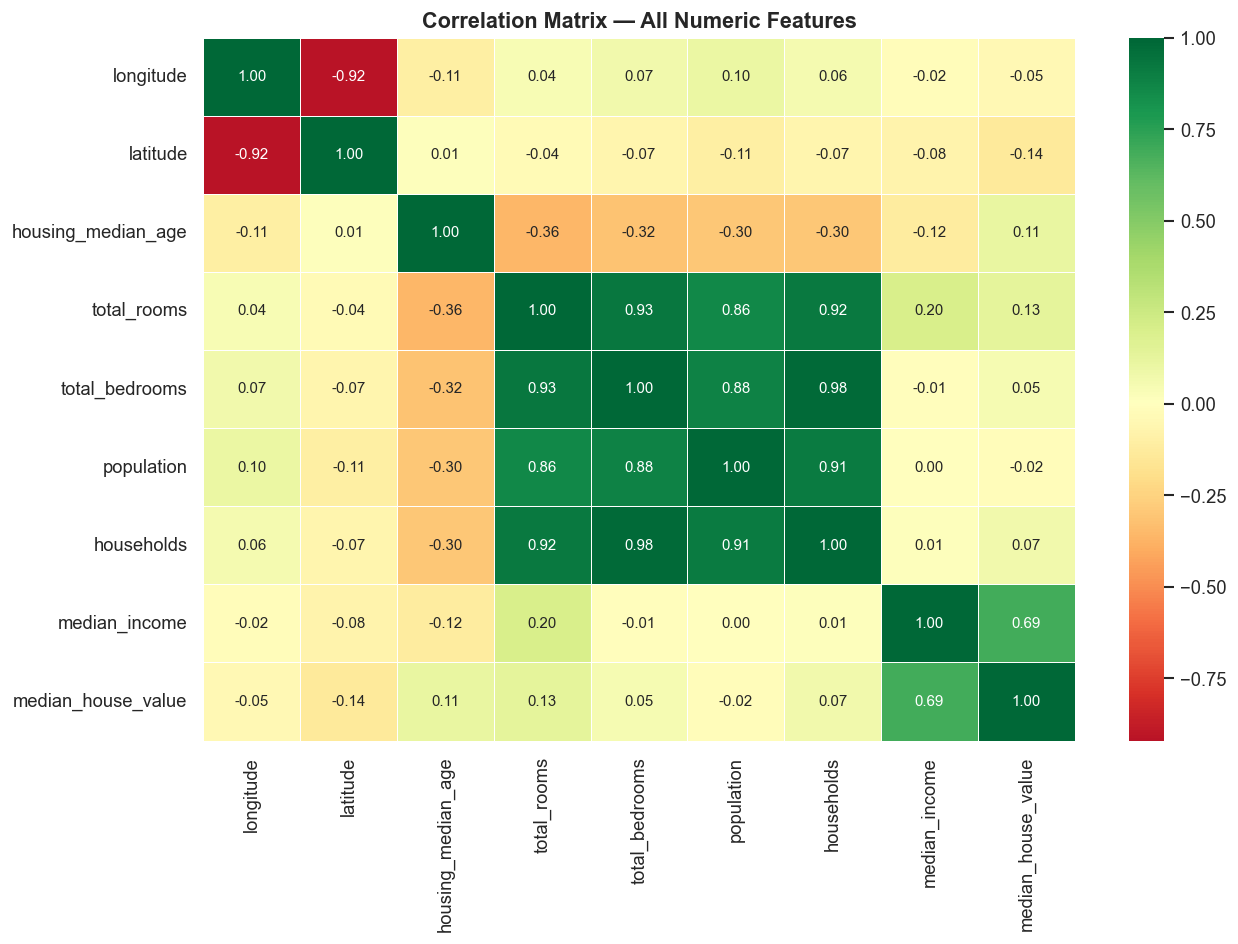


Top correlations with median_house_value:
median_house_value    1.00
median_income         0.69
total_rooms           0.13
housing_median_age    0.11
households            0.07
total_bedrooms        0.05
population           -0.02
longitude            -0.05
latitude             -0.14


In [12]:
plt.figure(figsize=(11, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr().round(2)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size':9})
plt.title('Correlation Matrix — All Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()
print('\nTop correlations with median_house_value:')
print(corr_matrix['median_house_value'].sort_values(ascending=False).to_string())

In [13]:
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

print(f'Median value used for imputation: {median_bedrooms}')
print(f'Missing values remaining        : {df.isnull().sum().sum()}')


Median value used for imputation: 435.0
Missing values remaining        : 0


In [14]:
df['rooms_per_household'] = df['total_rooms'] / df['households']

df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

df['population_per_household'] = df['population'] / df['households']

print('New features created:')
print('  rooms_per_household       — avg rooms per house unit')
print('  bedrooms_per_room         — bedroom density ratio')
print('  population_per_household  — avg people per house unit')
print(f'\nNew dataset shape: {df.shape}')
df[['rooms_per_household','bedrooms_per_room','population_per_household']].describe()

New features created:
  rooms_per_household       — avg rooms per house unit
  bedrooms_per_room         — bedroom density ratio
  population_per_household  — avg people per house unit

New dataset shape: (20640, 13)


,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.429000,0.213794,3.070655
std,2.474173,0.065248,10.386050
min,0.846154,0.037151,0.692308
25%,4.440716,0.175225,2.429741
50%,5.229129,0.203159,2.818116
75%,6.052381,0.240126,3.282261
max,141.909091,2.824675,1243.333333


In [15]:
print('Before encoding — ocean_proximity unique values:')
print(df['ocean_proximity'].value_counts().to_string())
print()

df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('After encoding — new columns added:')
new_cols = [c for c in df.columns if 'ocean_proximity' in c]
for col in new_cols:
    print(f'  {col}: {df[col].sum()} houses')

print(f'\nDataset shape after encoding: {df.shape}')


Before encoding — ocean_proximity unique values:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5

After encoding — new columns added:
  ocean_proximity_INLAND: 6551 houses
  ocean_proximity_ISLAND: 5 houses
  ocean_proximity_NEAR BAY: 2290 houses
  ocean_proximity_NEAR OCEAN: 2658 houses

Dataset shape after encoding: (20640, 16)


In [16]:
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [19]:
models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Lasso Regression'    : Lasso(alpha=1.0),
    'Decision Tree'       : DecisionTreeRegressor(random_state=42),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    print(f'Training: {name}...')

    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE ($)' : round(mae,  2),
        'MSE ($²)': round(mse,  2),
        'RMSE ($)': round(rmse, 2),
        'R² Score': round(r2,   4)
    })


Training: Linear Regression...
Training: Ridge Regression...
Training: Lasso Regression...
Training: Decision Tree...
Training: Random Forest...
Training: Gradient Boosting...


In [21]:
results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

print('='*75)
print('          MODEL PERFORMANCE COMPARISON (sorted by R² Score)')
print('='*75)
print(results_df.to_string())
print('='*75)
print(f'\n Best Model: {results_df.iloc[0]["Model"]} (R² = {results_df.iloc[0]["R² Score"]})')

          MODEL PERFORMANCE COMPARISON (sorted by R² Score)
               Model   MAE ($)      MSE ($²)  RMSE ($)  R² Score
1      Random Forest  32328.37  2.535787e+09  50356.60    0.8065
2  Gradient Boosting  36589.32  2.874653e+09  53615.79    0.7806
3  Linear Regression  50888.66  5.280716e+09  72668.54    0.5970
4   Ridge Regression  50888.32  5.280398e+09  72666.35    0.5970
5   Lasso Regression  50888.05  5.280496e+09  72667.02    0.5970
6      Decision Tree  44339.82  5.298199e+09  72788.73    0.5957

 Best Model: Random Forest (R² = 0.8065)


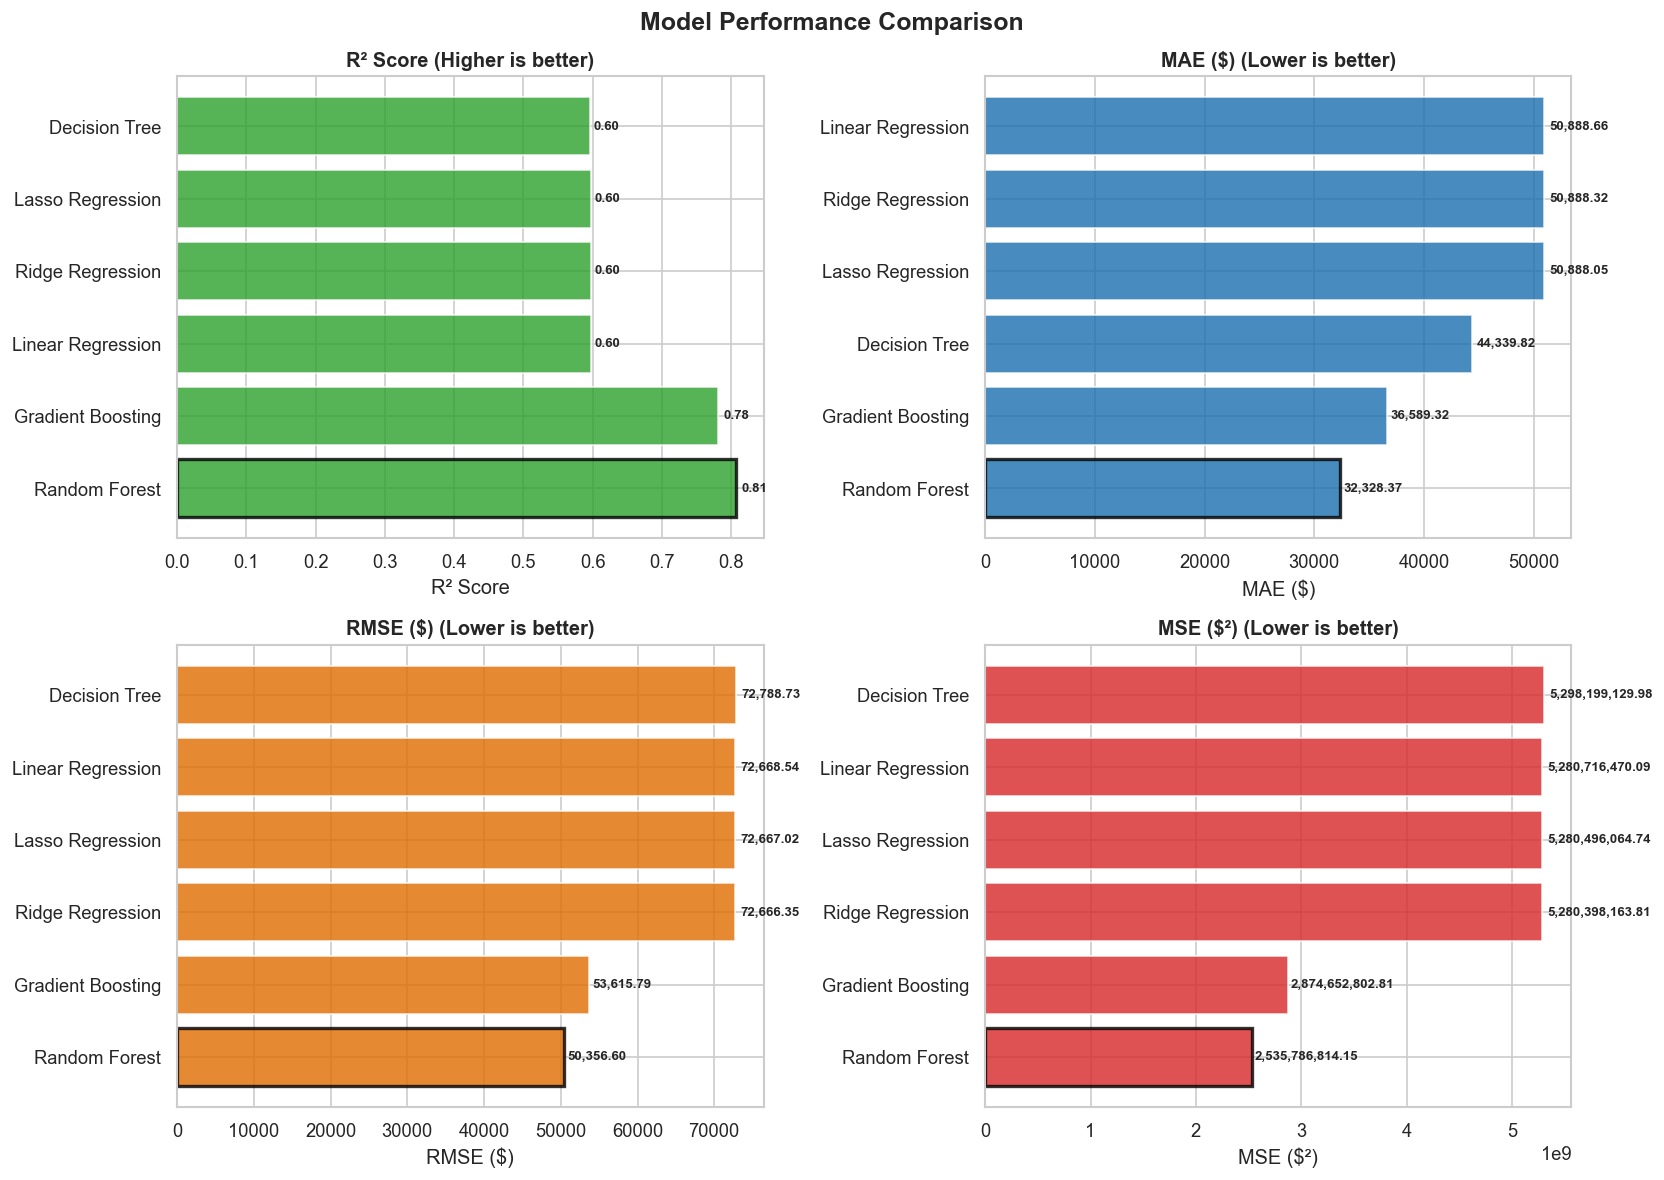

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

metrics   = ['R² Score', 'MAE ($)', 'RMSE ($)', 'MSE ($²)']
colors    = ['#2ca02c','#1a6faf','#e06c00','#d62728']
ascending = [False, True, True, True]

for ax, metric, color, asc in zip(axes.flatten(), metrics, colors, ascending):
    sorted_df = results_df.sort_values(metric, ascending=asc)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=color, alpha=0.8, edgecolor='white')
    bars[0].set_edgecolor('black')
    bars[0].set_linewidth(2)
    for bar in bars:
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():,.2f}', va='center', fontsize=8, fontweight='bold')
    ax.set_title(f'{metric} ({'Higher is better' if not asc else 'Lower is better'})',
                 fontweight='bold')
    ax.set_xlabel(metric)

plt.tight_layout()
plt.show()

In [26]:
cv_models = {
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Linear Regression' : LinearRegression(),
}

print('5-Fold Cross Validation Results (R² Score):')
print(f'  {"Model":<25} {"Mean R²":>10} {"Std Dev":>10} {"Min":>10} {"Max":>10}')
print('-' * 68)

for name, model in cv_models.items():
    if name == 'Linear Regression':
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f'  {name:<25} {scores.mean():>10.4f} {scores.std():>10.4f} {scores.min():>10.4f} {scores.max():>10.4f}')


5-Fold Cross Validation Results (R² Score):
  Model                        Mean R²    Std Dev        Min        Max
--------------------------------------------------------------------
  Random Forest                 0.8111     0.0078     0.7965     0.8192
  Gradient Boosting             0.7921     0.0048     0.7827     0.7955
  Linear Regression             0.6555     0.0120     0.6325     0.6673


Feature Importance (Random Forest):
  median_income                       0.4817  ████████████████████████████████████████████████
  ocean_proximity_INLAND              0.1375  █████████████
  population_per_household            0.1216  ████████████
  longitude                           0.0579  █████
  latitude                            0.0565  █████
  housing_median_age                  0.0443  ████
  rooms_per_household                 0.0260  ██
  bedrooms_per_room                   0.0242  ██
  total_rooms                         0.0125  █
  total_bedrooms                      0.0121  █
  population                          0.0117  █
  households                          0.0104  █
  ocean_proximity_NEAR OCEAN          0.0025  
  ocean_proximity_NEAR BAY            0.0008  
  ocean_proximity_ISLAND              0.0001  


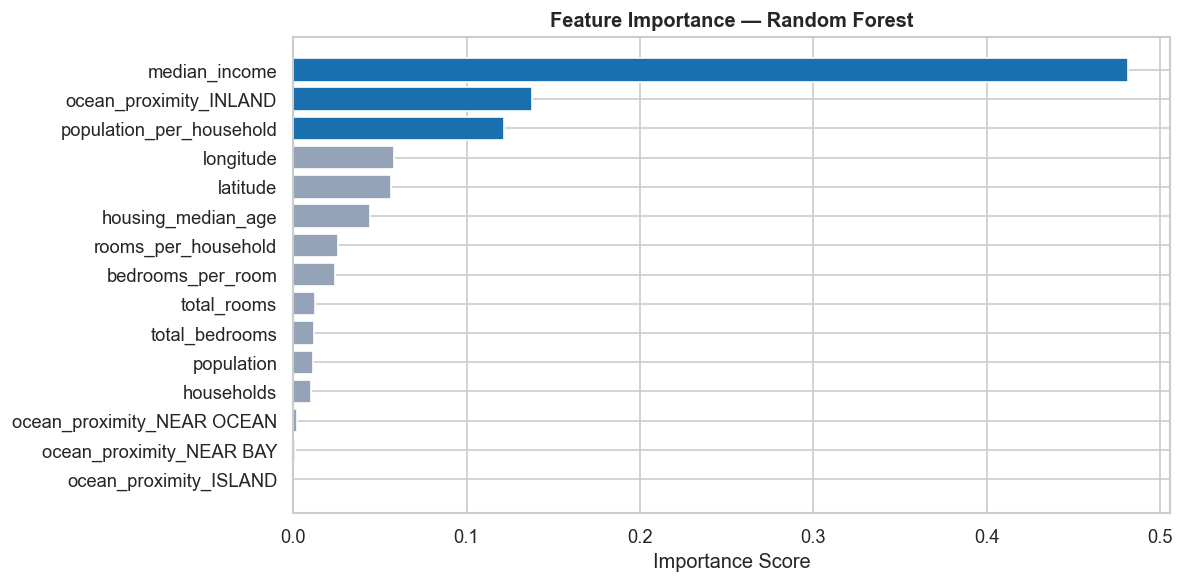


 Most important feature: median_income (0.4817)


In [27]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print('Feature Importance (Random Forest):')
for feat, imp in feat_imp.items():
    bar = '█' * int(imp * 100)
    print(f'  {feat:<35} {imp:.4f}  {bar}')

plt.figure(figsize=(10, 5))
colors = ['#1a6faf' if i < 3 else '#94a3b8' for i in range(len(feat_imp))]
plt.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1], edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
print(f'\n Most important feature: {feat_imp.idxmax()} ({feat_imp.max():.4f})')

In [28]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2']
}

print('Starting GridSearchCV...')
print(f'Total combinations to try: {3*3*2*2} × 3 folds = {3*3*2*2*3} fits')
print('(This may take a few minutes...)\n')

grid_search = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42),
    param_grid = param_grid,
    cv         = 3,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print(f'\n GridSearchCV complete!')
print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV R² Score: {grid_search.best_score_:.4f}')

Starting GridSearchCV...
Total combinations to try: 36 × 3 folds = 108 fits
(This may take a few minutes...)

Fitting 3 folds for each of 36 candidates, totalling 108 fits

 GridSearchCV complete!
Best Parameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV R² Score: 0.8115


In [29]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

mae_best  = mean_absolute_error(y_test, y_pred_best)
mse_best  = mean_squared_error(y_test,  y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best   = r2_score(y_test, y_pred_best)

rf_base   = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
r2_base   = r2_score(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

print('='*58)
print('     TUNED MODEL vs BASE MODEL — COMPARISON')
print('='*58)
print(f'  {"Metric":<12}  {"Base RF":>15}  {"Tuned RF":>15}')
print('-'*58)
print(f'  {"R² Score":<12}  {r2_base:>15.4f}  {r2_best:>15.4f}  {" Improved" if r2_best > r2_base else ""}')
print(f'  {"RMSE ($)":<12}  ${rmse_base:>14,.0f}  ${rmse_best:>14,.0f}')
print(f'  {"MAE ($)":<12}  — {" "*13}  ${mae_best:>14,.0f}')
print('='*58)
print(f'\n Best Model: Tuned Random Forest')
print(f'   R² Score : {r2_best:.4f}  ({r2_best*100:.2f}% variance explained)')
print(f'   MAE      : ${mae_best:,.0f} average price error')
print(f'   RMSE     : ${rmse_best:,.0f}')

     TUNED MODEL vs BASE MODEL — COMPARISON
  Metric                Base RF         Tuned RF
----------------------------------------------------------
  R² Score               0.8065           0.8114   Improved
  RMSE ($)      $        50,357  $        49,718
  MAE ($)       —                $        33,398

 Best Model: Tuned Random Forest
   R² Score : 0.8114  (81.14% variance explained)
   MAE      : $33,398 average price error
   RMSE     : $49,718


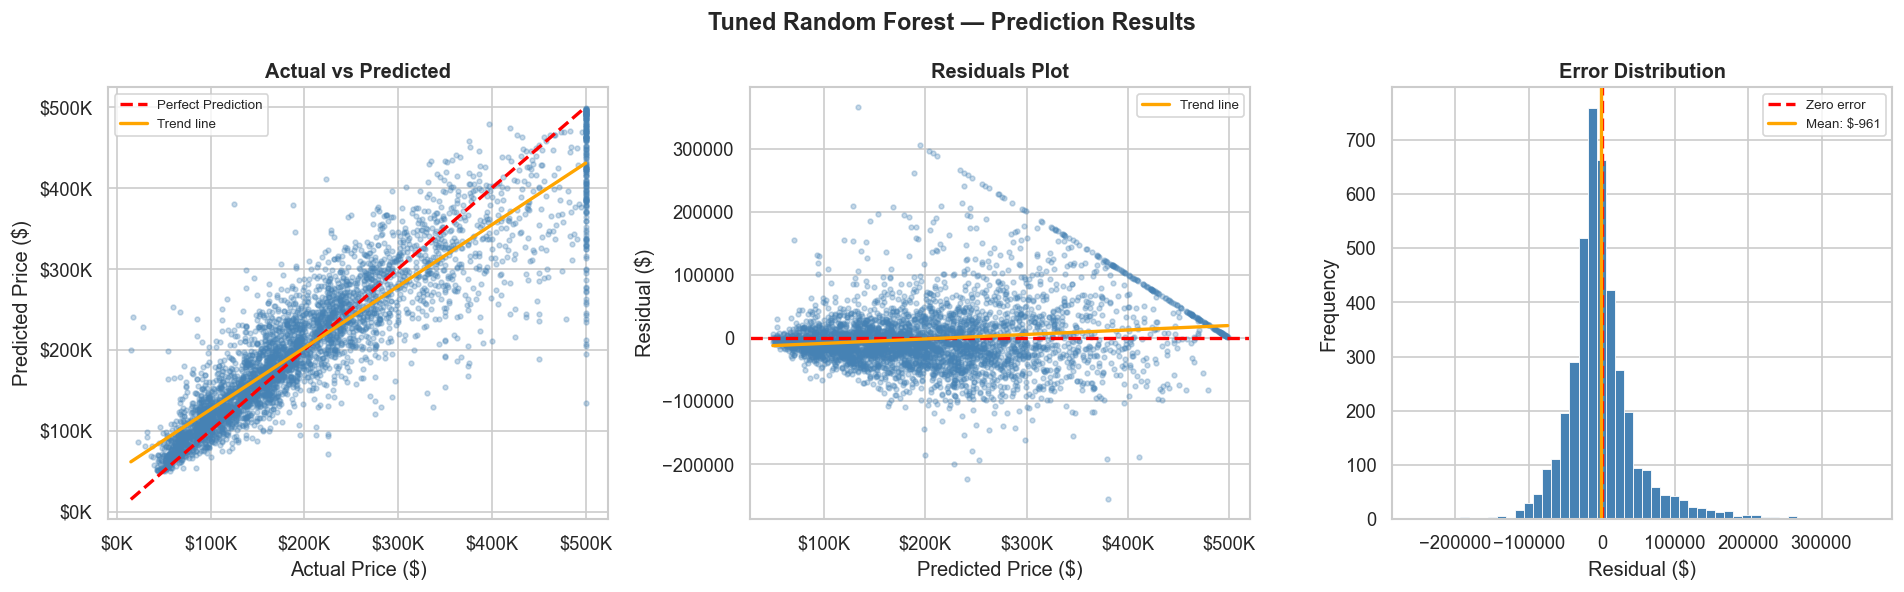

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Tuned Random Forest — Prediction Results', fontsize=14, fontweight='bold')

axes[0].scatter(y_test, y_pred_best, color='steelblue', alpha=0.3, s=8)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
m, b = np.polyfit(y_test, y_pred_best, 1)
x_line = np.linspace(y_test.min(), y_test.max(), 100)
axes[0].plot(x_line, m*x_line+b, color='orange', linewidth=2, label='Trend line')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, color='steelblue', alpha=0.3, s=8)
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
m2, b2 = np.polyfit(y_pred_best, residuals, 1)
x2 = np.linspace(y_pred_best.min(), y_pred_best.max(), 100)
axes[1].plot(x2, m2*x2+b2, color='orange', linewidth=2, label='Trend line')
axes[1].set_title('Residuals Plot')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

axes[2].hist(residuals, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[2].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero error')
axes[2].axvline(residuals.mean(), color='orange', linewidth=2,
                label=f'Mean: ${residuals.mean():,.0f}')
axes[2].set_title('Error Distribution')
axes[2].set_xlabel('Residual ($)')
axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [32]:
tuned_result = {
    'Model'   : 'Random Forest (Tuned)',
    'MAE ($)' : round(mae_best,  2),
    'MSE ($²)': round(mse_best,  2),
    'RMSE ($)': round(rmse_best, 2),
    'R² Score': round(r2_best,   4)
}
final_df = pd.concat([results_df, pd.DataFrame([tuned_result])],
                     ignore_index=True)
final_df = final_df.sort_values('R² Score', ascending=False).reset_index(drop=True)
final_df.index = final_df.index + 1

print('='*80)
print('         FINAL MODEL COMPARISON — ALL MODELS INCLUDING TUNED')
print('='*80)
print(final_df.to_string())
print('='*80)
print(f'\n🏆 WINNER: {final_df.iloc[0]["Model"]}')
print(f'   R² Score : {final_df.iloc[0]["R² Score"]} ({final_df.iloc[0]["R² Score"]*100:.2f}% variance explained)')
print(f'   MAE      : ${final_df.iloc[0]["MAE ($)"]:,.0f}')
print(f'   RMSE     : ${final_df.iloc[0]["RMSE ($)"]:,.0f}')

         FINAL MODEL COMPARISON — ALL MODELS INCLUDING TUNED
                   Model   MAE ($)      MSE ($²)  RMSE ($)  R² Score
1  Random Forest (Tuned)  33398.18  2.471891e+09  49718.12    0.8114
2          Random Forest  32328.37  2.535787e+09  50356.60    0.8065
3      Gradient Boosting  36589.32  2.874653e+09  53615.79    0.7806
4      Linear Regression  50888.66  5.280716e+09  72668.54    0.5970
5       Ridge Regression  50888.32  5.280398e+09  72666.35    0.5970
6       Lasso Regression  50888.05  5.280496e+09  72667.02    0.5970
7          Decision Tree  44339.82  5.298199e+09  72788.73    0.5957

 WINNER: Random Forest (Tuned)
   R² Score : 0.8114 (81.14% variance explained)
   MAE      : $33,398
   RMSE     : $49,718


### Key Findings
- **`median_income`** is the strongest predictor of house price (highest feature importance)
- **`ocean_proximity`** significantly affects price — coastal houses are more expensive
- **Random Forest** outperforms all linear models due to non-linear relationships in data
- **Hyperparameter tuning** further improved R² score over the baseline Random Forest
- Feature engineering (rooms_per_household, bedrooms_per_room) added meaningful signal
